In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import explained_variance_score

In [7]:
# carga el dataset
df = pd.read_csv("PANEL_FINAL_2022_2024_CRIMEN.csv")
df.head()

,UBIGEO6,ANIO,MES,inseg_total,inseg_dia,conf_pnp_baja,evita_salir_noche_bin,n_encuestas,suma_pesos,nombredd,nombrepp,nombredi,pob,esp_vida,anios_edu,per_cap,idh,denuncias_total,tasa_criminalidad
0,10101,2022,1,0.185289,0.043550,0.751245,0.307762,56,1395.702140,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,40274.0,75.738388,9.405192,1038.273926,0.662125,103.0,255.748125
1,10101,2022,2,0.173709,0.051461,0.610827,0.191006,108,4315.324965,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,40274.0,75.738388,9.405192,1038.273926,0.662125,103.0,255.748125
2,10101,2022,3,0.233575,0.095531,0.668819,0.306873,120,4354.637192,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,40274.0,75.738388,9.405192,1038.273926,0.662125,94.0,233.401202
3,10101,2022,4,0.338828,0.021756,0.722122,0.227621,58,1901.875511,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,40274.0,75.738388,9.405192,1038.273926,0.662125,88.0,218.503253
4,10101,2022,5,0.203889,0.041428,0.793434,0.218714,53,2422.638909,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,40274.0,75.738388,9.405192,1038.273926,0.662125,95.0,235.884193


# Análisis del dataset

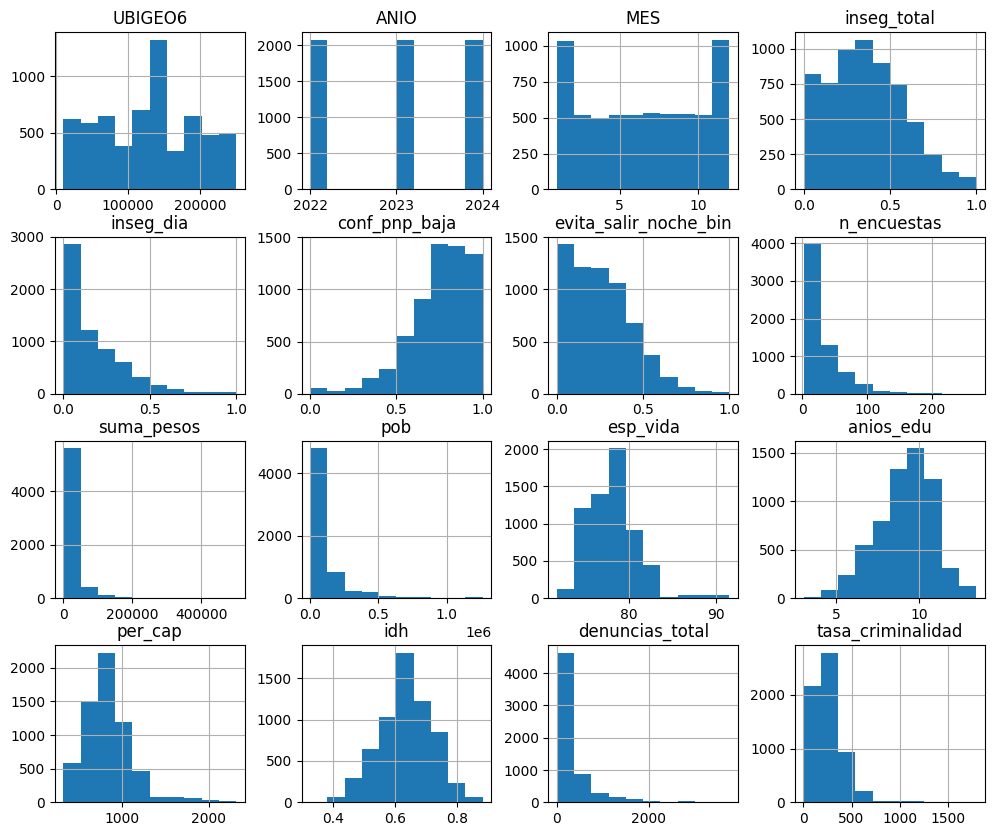

In [8]:
# muestra la distribucion de las variables
df.hist(figsize=[12,10])
plt.show()

In [9]:
df.describe()

,UBIGEO6,ANIO,MES,inseg_total,inseg_dia,conf_pnp_baja,evita_salir_noche_bin,n_encuestas,suma_pesos,pob,esp_vida,anios_edu,per_cap,idh,denuncias_total,tasa_criminalidad
count,6231.000000,6231.000000,6231.000000,6227.000000,6227.000000,6180.000000,6231.000000,6231.000000,6231.000000,6.230000e+03,6230.000000,6230.000000,6230.000000,6230.000000,6171.000000,6171.000000
mean,129145.972396,2023.000481,6.521425,0.364003,0.169311,0.754029,0.255228,34.069491,20784.801532,1.066230e+05,78.193478,9.166204,843.400195,0.637551,304.345973,256.987926
std,66724.144574,0.816464,3.447866,0.222743,0.180330,0.186200,0.183134,26.996983,34903.986656,1.556466e+05,2.798563,1.685288,279.060105,0.084732,464.551199,162.024989
min,10101.000000,2022.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,36.066138,1.733000e+03,71.850929,3.041738,323.910461,0.327453,1.000000,3.136566
25%,70107.000000,2022.000000,4.000000,0.198996,0.000000,0.658609,0.111111,18.000000,3964.843094,1.999950e+04,75.942352,8.107843,665.299866,0.585570,35.000000,151.540238
50%,140105.000000,2023.000000,7.000000,0.353274,0.119487,0.777778,0.236881,23.000000,9273.894206,5.493300e+04,78.446907,9.351027,812.327454,0.640217,120.000000,228.439776
75%,180301.000000,2024.000000,10.000000,0.516501,0.264348,0.883574,0.373597,41.000000,22628.635846,1.181960e+05,79.596907,10.442152,970.553955,0.695640,375.500000,329.403571
max,250305.000000,2024.000000,12.000000,1.000000,1.000000,1.000000,1.000000,268.000000,500795.025524,1.264060e+06,91.485977,13.456955,2313.544434,0.883117,3764.000000,1793.532247


In [10]:
df.shape

(6231, 19)

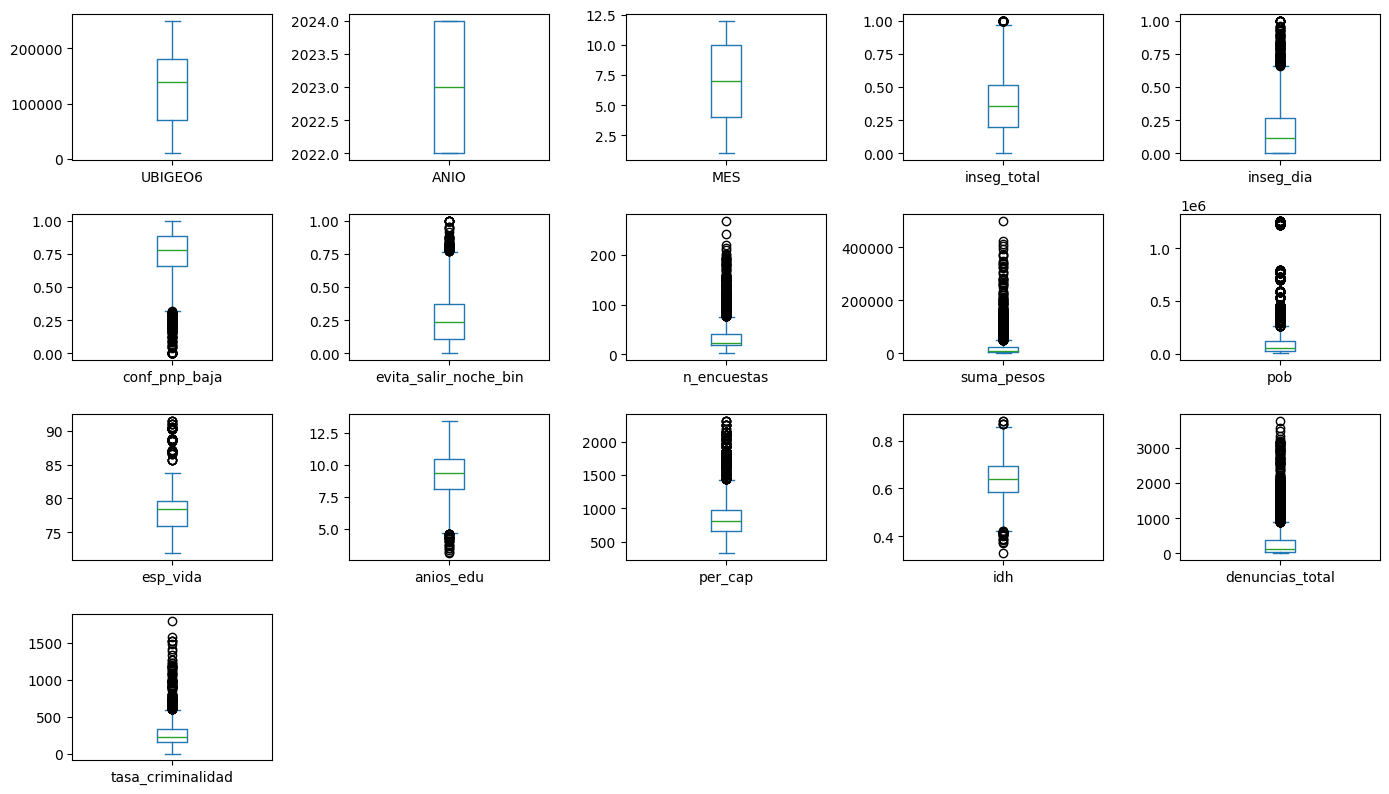

In [11]:
#vemos boxplot
numeric_cols = df.select_dtypes(include=[np.number]).columns

df[numeric_cols].plot(kind='box', figsize=(14, 8), subplots=True, layout=(4, 5), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

# Limpieza de datos

In [78]:
# Eliminación de valores nulos
df = df.dropna(subset=["tasa_criminalidad"])
# eliminamos duplicados
df.drop_duplicates(inplace=True)
# Columnas a imputar con MEDIANA
mediana_cols = [
    'denuncias_total',
    'conf_pnp_baja',
    'inseg_dia',
    'inseg_total',
    'per_cap',
    'pob'
]

# Columnas a imputar con MEDIA
media_cols = [
    'esp_vida',
    'anios_edu',
    'idh'
]

# Imputación con mediana
for col in mediana_cols:
    df[col] = df[col].fillna(df[col].median())

# Imputación con media
for col in media_cols:
    df[col] = df[col].fillna(df[col].mean())

print("Imputación completada.")
# ---- NA ----
print("\n➡️ VALORES NULOS POR COLUMNA:")
print(df.isna().sum())

Imputación completada.

➡️ VALORES NULOS POR COLUMNA:
UBIGEO6                  0
ANIO                     0
MES                      0
inseg_total              0
inseg_dia                0
conf_pnp_baja            0
evita_salir_noche_bin    0
n_encuestas              0
suma_pesos               0
nombredd                 0
nombrepp                 0
nombredi                 0
pob                      0
esp_vida                 0
anios_edu                0
per_cap                  0
idh                      0
denuncias_total          0
tasa_criminalidad        0
dtype: int64


## Matriz de Correlación

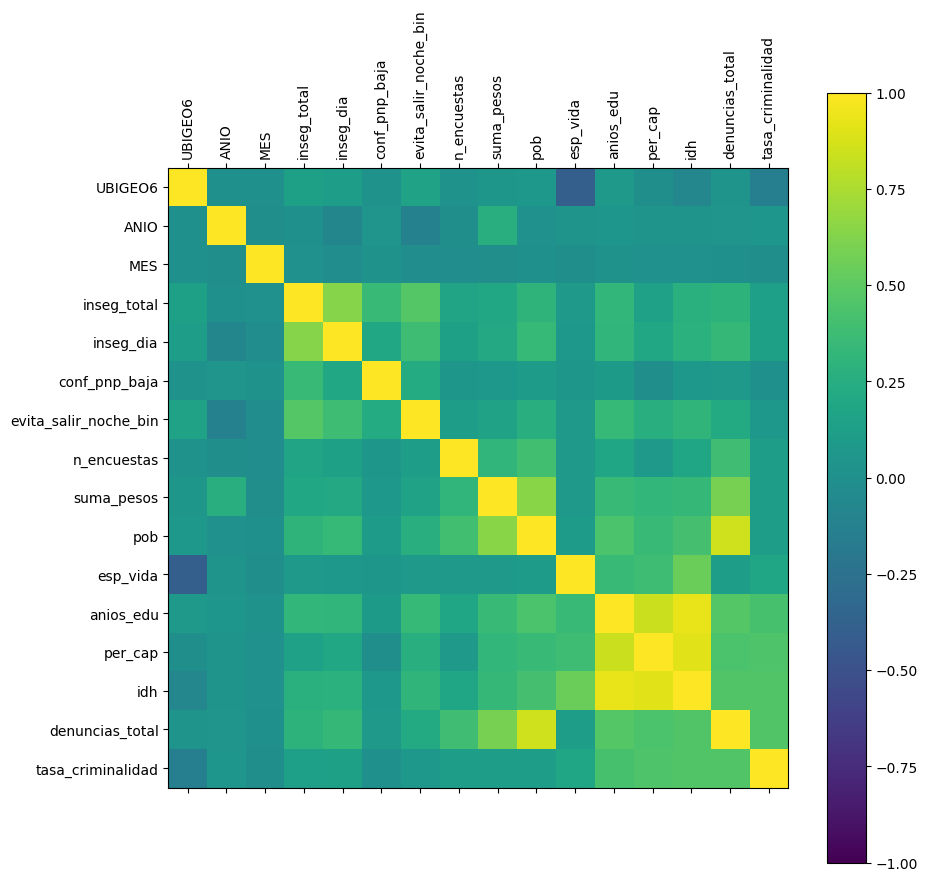

In [13]:
# plotea la matriz de correlacion
correlations = df.select_dtypes(include=[np.number]).corr()
fig = plt.figure(figsize=[10,10])
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)

ticks = np.arange(len(correlations.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(correlations.columns, rotation=90)
ax.set_yticklabels(correlations.columns)

plt.show()

In [16]:
correlations

,UBIGEO6,ANIO,MES,inseg_total,inseg_dia,conf_pnp_baja,evita_salir_noche_bin,n_encuestas,suma_pesos,pob,esp_vida,anios_edu,per_cap,idh,denuncias_total,tasa_criminalidad
UBIGEO6,1.000000,0.002895,0.007375,0.134597,0.123745,0.022169,0.149374,0.028485,0.059803,0.066655,-0.393403,0.081634,-0.005688,-0.072230,0.035348,-0.140620
ANIO,0.002895,1.000000,-0.001518,0.003666,-0.080694,0.041306,-0.120044,-0.006569,0.251904,0.009851,0.037365,0.051102,0.032948,0.037435,0.040347,0.052588
MES,0.007375,-0.001518,1.000000,0.015310,-0.015796,0.020312,-0.016217,-0.019749,-0.012418,0.007034,-0.000993,0.018836,0.013396,0.014281,0.002152,-0.003390
inseg_total,0.134597,0.003666,0.015310,1.000000,0.636711,0.344757,0.470427,0.164824,0.191044,0.304160,0.071398,0.324170,0.141676,0.272351,0.292082,0.125535
inseg_dia,0.123745,-0.080694,-0.015796,0.636711,1.000000,0.201928,0.382355,0.135967,0.208418,0.336728,0.063668,0.317437,0.191613,0.278087,0.334525,0.133075
conf_pnp_baja,0.022169,0.041306,0.020312,0.344757,0.201928,1.000000,0.227138,0.059726,0.068018,0.102391,0.056626,0.093680,-0.003334,0.067073,0.081571,0.006872
evita_salir_noche_bin,0.149374,-0.120044,-0.016217,0.470427,0.382355,0.227138,1.000000,0.123693,0.148930,0.255981,0.077278,0.342739,0.250062,0.309155,0.224909,0.067839
n_encuestas,0.028485,-0.006569,-0.019749,0.164824,0.135967,0.059726,0.123693,1.000000,0.314152,0.397509,0.084875,0.179715,0.082258,0.176937,0.384475,0.122395
suma_pesos,0.059803,0.251904,-0.012418,0.191044,0.208418,0.068018,0.148930,0.314152,1.000000,0.642868,0.075557,0.356910,0.323105,0.331031,0.588208,0.116228
pob,0.066655,0.009851,0.007034,0.304160,0.336728,0.102391,0.255981,0.397509,0.642868,1.000000,0.107788,0.431297,0.358734,0.406790,0.857448,0.110456


La variable idh presenta una correlación fuerte (mayor a 0.9) con las variables anios_edu y per_cap

# Selección de variables y división en train-test

In [17]:
# Eliminamos: UBIGEO (ID), Nombres (Texto), Denuncias (Leakage, parte de la fórmula para tasa_criminalidad), Encuestas (Irrelevante)
# idh fue elimnado por su alta correlación
cols_to_keep = [
     'MES',
    'pob', 'per_cap', 'esp_vida', 'anios_edu', # Variables socioeconómicas
    'inseg_total', 'inseg_dia', 'conf_pnp_baja', 'evita_salir_noche_bin' # Percepción
]
target_col = 'tasa_criminalidad'

X = df[cols_to_keep].copy()
y = df[target_col].copy()

# Manejo de 'MES' para capturar estacionalidad con Seno y Coseno
X['MES_sin'] = np.sin(2 * np.pi * X['MES'] / 12)
X['MES_cos'] = np.cos(2 * np.pi * X['MES'] / 12)
# Eliminar la columna 'MES' original después de la transformación
X = X.drop(columns=['MES'])

# Transformaciones logaritmicas
#Esto se realizó basado en los histogramas anteriormente mostrados
vars_skewed = ['pob', 'per_cap']

for col in vars_skewed:
  X[col] = np.log1p(X[col])

#También se realizó para la variable target
y_log = np.log1p(y)

array([[<Axes: title={'center': 'pob'}>,
        <Axes: title={'center': 'per_cap'}>,
        <Axes: title={'center': 'esp_vida'}>],
       [<Axes: title={'center': 'anios_edu'}>,
        <Axes: title={'center': 'inseg_total'}>,
        <Axes: title={'center': 'inseg_dia'}>],
       [<Axes: title={'center': 'conf_pnp_baja'}>,
        <Axes: title={'center': 'evita_salir_noche_bin'}>,
        <Axes: title={'center': 'MES_sin'}>],
       [<Axes: title={'center': 'MES_cos'}>, <Axes: >, <Axes: >]],
      dtype=object)

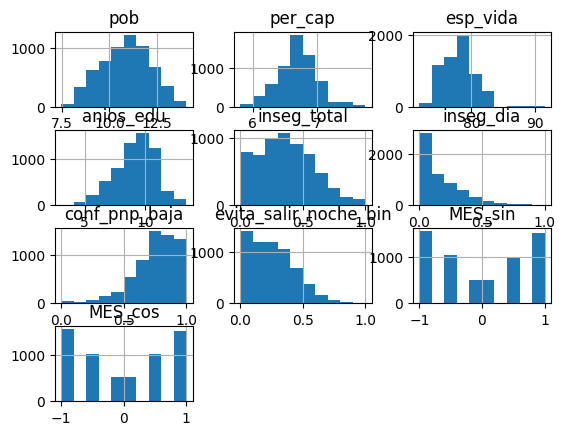

In [18]:
X.hist()

<Axes: >

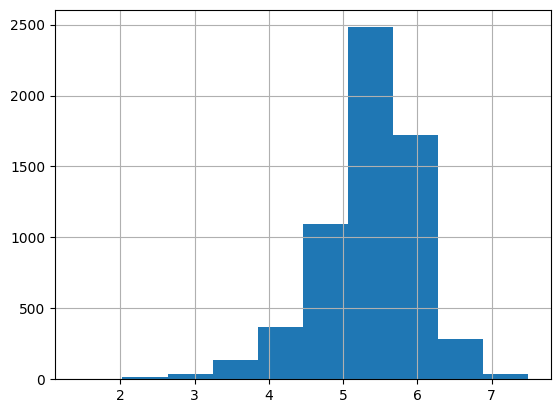

In [19]:
y_log.hist()

In [20]:
# Split train/test
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Escalado con StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training: %d ejemplos. Test: %d ejemplos' % (len(y_train_log), len(y_test_log)))

Training: 4936 ejemplos. Test: 1235 ejemplos


# Comparación de algoritmos

In [80]:
modelos = {
    "Regresión Lineal": LinearRegression(),
    "KNN (k=3)": KNeighborsRegressor(n_neighbors=3, weights='distance'),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5, weights='distance'),
    "XGBoost": XGBRegressor(random_state=42)}

# Comparación de nmse (Usando Cross-Validation)
print(f"{'Modelo':<20} | {'Neg MSE (CV)':<15} | {'Desv. Estándar(CV)':<10}")
print("-" * 65)
results = []
names = []

for nombre, modelo in modelos.items():

    cv_scores = cross_val_score(modelo, X_train, y_train_log,
                                cv=10, scoring='neg_mean_squared_error')

    neg_mse_promedio = cv_scores.mean()

    # B) Entrenar y evaluar métricas tradicionales en el Test Set
    modelo.fit(X_train_scaled, y_train_log)
    y_pred_log = modelo.predict(X_test_scaled)

    results.append(cv_scores) #Para los boxplots
    names.append(nombre)

    print(f"{nombre:<20} | {neg_mse_promedio:.4f}          |  {cv_scores.std():.6f}")

Modelo               | Neg MSE (CV)    | Desv. Estándar(CV)
-----------------------------------------------------------------
Regresión Lineal     | -0.3195          |  0.027441
KNN (k=3)            | -0.2880          |  0.024407
KNN (k=5)            | -0.2747          |  0.026082
XGBoost              | -0.1673          |  0.017626


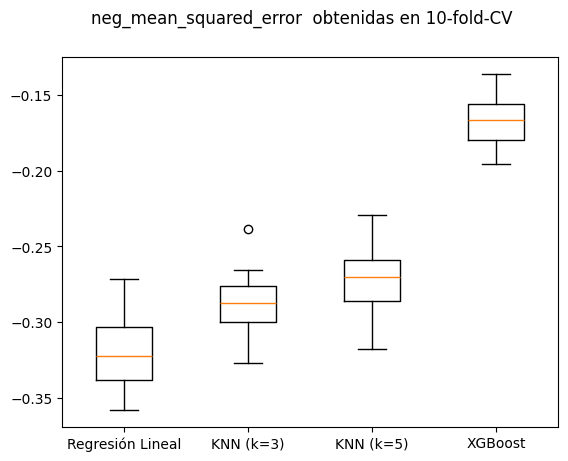

In [63]:
# Muestra graficamente los resultados de neg_mean_absolute_error  en crossvalidacion de los Algoritmos evaluados
fig = plt.figure()
fig.suptitle('neg_mean_squared_error  obtenidas en 10-fold-CV')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

# Ajuste del modelo escogido

Árboles    | R2         | RMSE      
-----------------------------------
50         | 0.5479     | 110.10
100        | 0.6261     | 100.12
200        | 0.6928     | 90.76
300        | 0.7101     | 88.16
500        | 0.7193     | 86.76
700        | 0.7189     | 86.81


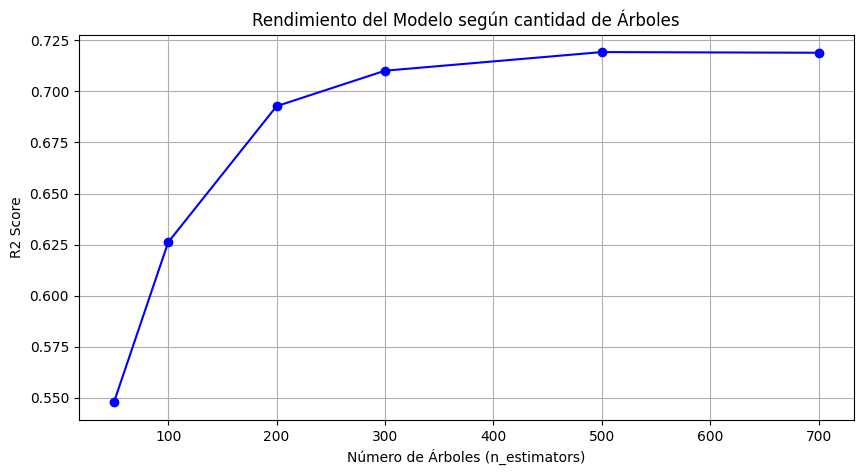

In [61]:
import matplotlib.pyplot as plt

# 1. Definimos solo los valores de árboles que queremos probar
valores_n_estimators = [50, 100, 200, 300, 500,700]
resultados_r2 = []
resultados_rmse = []

print(f"{'Árboles':<10} | {'R2':<10} | {'RMSE':<10}")
print("-" * 35)

for n in valores_n_estimators:
    modelo = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=n,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )

    modelo.fit(X_train_scaled, y_train_log)

    # Predecir
    pred_log = modelo.predict(X_test_scaled)

    # Volver a escala real
    y_real = np.expm1(y_test_log)
    pred_real = np.expm1(pred_log)

    # Guardar métricas
    r2 = r2_score(y_real, pred_real)
    rmse = np.sqrt(mean_squared_error(y_real, pred_real))

    resultados_r2.append(r2)
    resultados_rmse.append(rmse)

    print(f"{n:<10} | {r2:.4f}     | {rmse:.2f}")

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(valores_n_estimators, resultados_r2, marker='o', linestyle='-', color='b')
plt.title('Rendimiento del Modelo según cantidad de Árboles')
plt.xlabel('Número de Árboles (n_estimators)')
plt.ylabel('R2 Score')
plt.grid(True)
plt.show()

In [60]:
modelo_final = XGBRegressor(objective='reg:squarederror', n_estimators=500, max_depth=5,learning_rate=0.1, random_state=42)
modelo_final.fit(X_train_scaled, y_train_log)

y_pred_log = modelo_final.predict(X_test_scaled)
y_test_real = np.expm1(y_test_log)
y_pred_real = np.expm1(y_pred_log)

print("Mean squared error:", mean_squared_error(y_test_real, y_pred_real))
print("Mean absolute error:", mean_absolute_error(y_test_real, y_pred_real))
print("Explained variance score:", explained_variance_score(y_test_real, y_pred_real))
print("R2 score:", r2_score(y_test_real, y_pred_real))

Mean squared error: 7526.915741121703
Mean absolute error: 54.09097914435005
Explained variance score: 0.7268645515733825
R2 score: 0.719255900912291


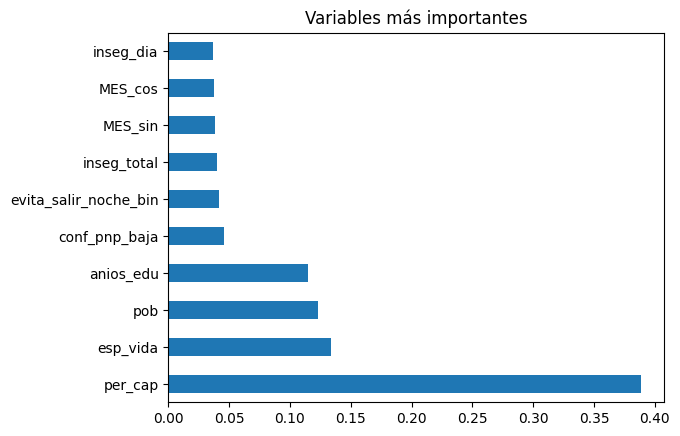

In [25]:
# Ver importancia
feat_importances = pd.Series(modelo_final.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Variables más importantes")
plt.show()

Text(0.05, 0.95, 'R² = 0.7193')

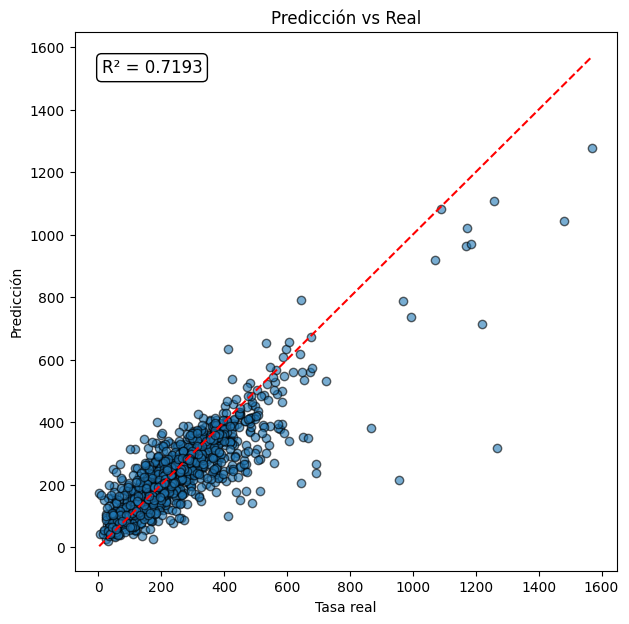

In [26]:
# Gráfico de dispersión

plt.figure(figsize=(7,7))
plt.scatter(y_test_real, y_pred_real, edgecolor="k", alpha=0.6)
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()], "r--")
plt.xlabel("Tasa real")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")

# R2
r2 = r2_score(y_test_real, y_pred_real)

# Texto del R2 dentro del gráfico
plt.text(
    0.05, 0.95,
    f"R² = {r2:.4f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
)

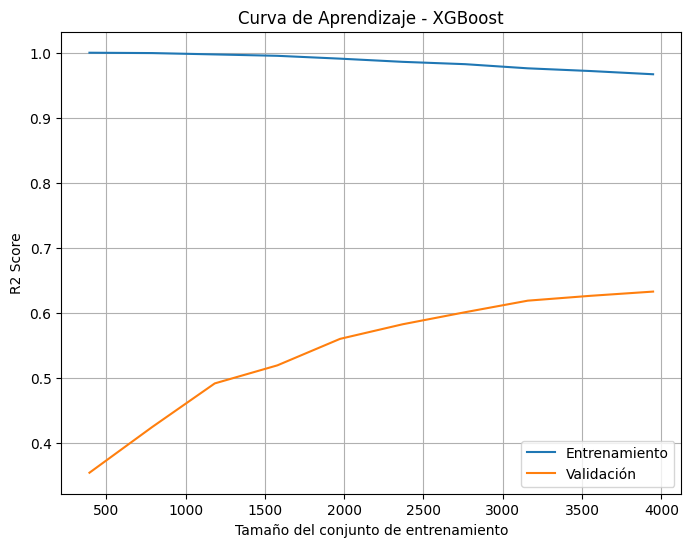

In [75]:
#Curva de aprendizaje del modelo
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    modelo_final,
    X_train_scaled,
    y_train_log,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Entrenamiento")
plt.plot(train_sizes, test_mean, label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("R2 Score")
plt.title("Curva de Aprendizaje - XGBoost")
plt.legend()
plt.grid()
plt.show()


# Ajuste para disminuir overfitting

In [76]:
modelo_ajustado = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.02,
    max_depth=5,
    min_child_weight=2,

    reg_alpha=0.5,           # Regularización

    random_state=42,
    n_jobs=-1
)

modelo_ajustado.fit(X_train_scaled, y_train_log)

y_pred_log = modelo_ajustado.predict(X_test_scaled)
y_test_real = np.expm1(y_test_log)
y_pred_real = np.expm1(y_pred_log)

print("Mean squared error:", mean_squared_error(y_test_real, y_pred_real))
print("Mean absolute error:", mean_absolute_error(y_test_real, y_pred_real))
print("Explained variance score:", explained_variance_score(y_test_real, y_pred_real))
print("R2 score:", r2_score(y_test_real, y_pred_real))

Mean squared error: 10500.318509600764
Mean absolute error: 63.45112581124752
Explained variance score: 0.6242936506206405
R2 score: 0.6083518719351906


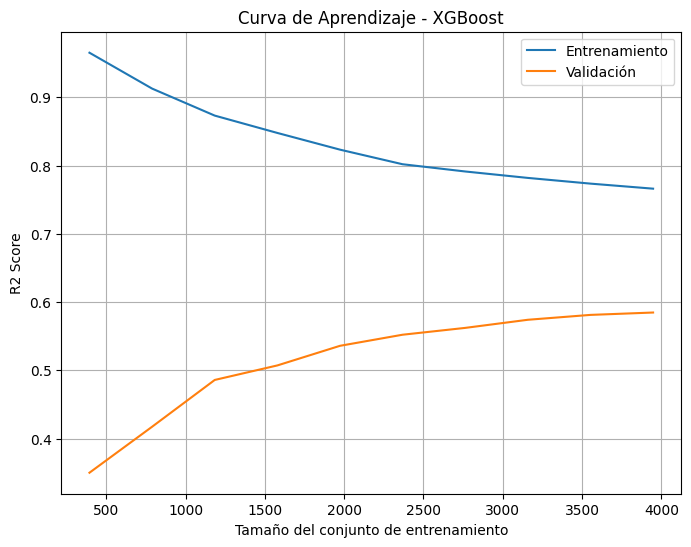

In [77]:
#Curva de aprendizaje del modelo regularizado
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    modelo_ajustado,
    X_train_scaled,
    y_train_log,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Entrenamiento")
plt.plot(train_sizes, test_mean, label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("R2 Score")
plt.title("Curva de Aprendizaje - XGBoost")
plt.legend()
plt.grid()
plt.show()